# Linear Regression implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **pandas** for tabular data handling, **numpy** for the vectorized math behind the model, **matplotlib** for visualization, and **load_breast_cancer** from scikit-learn as a real-data source.

In [31]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

### Loading Data

Loads the real Breast Cancer Wisconsin (Diagnostic) dataset and extracts **mean compactness** as the input feature (x) and **mean concavity** as the target (y) — two real, malignancy-associated tumor shape descriptors from 569 patient biopsies.

In [32]:
data = load_breast_cancer(as_frame=True)
df = data.frame

x_train = df["mean compactness"].values
y_train = df["mean concavity"].values

print(f"Number of examples: {len(x_train)}")

print(f"x range: {x_train.min():.4f} to {x_train.max():.4f}")
print(f"y range: {y_train.min():.4f} to {y_train.max():.4f}")

Number of examples: 569
x range: 0.0194 to 0.3454
y range: 0.0000 to 0.4268


### Visualization

Plots the raw data as a scatter plot to visually inspect the relationship between the two features before any model is built.

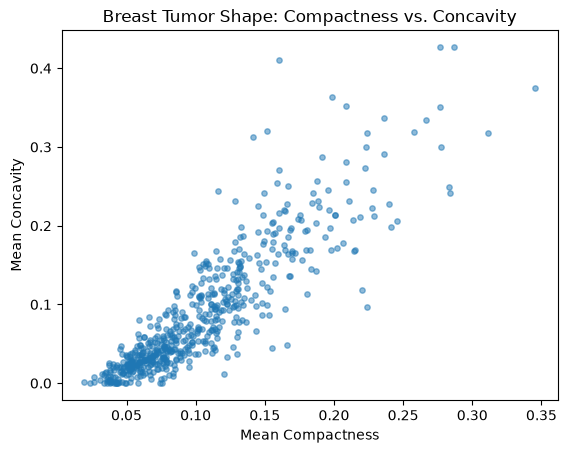

In [33]:
plt.scatter(x_train, y_train, s=15, alpha=0.5)
plt.xlabel("Mean Compactness")
plt.ylabel("Mean Concavity")
plt.title("Breast Tumor Shape: Compactness vs. Concavity")
plt.show()

Shows a clear, real upward trend, as compactness increases, concavity tends to increase with it.

### Cost Function

Defines the Mean Squared Error cost function, which quantifies how far the model's current line **(w, b)** is from the real data on average. This is the function gradient descent will work to minimize. Implemented vectorized with numpy so it runs efficiently across all 569 examples at once, rather than looping row by row.

In [34]:
def cost_function(x, y, w, b):
    m = len(x)
    f = w * x + b
    cost = np.sum((f - y) ** 2)
    total_cost = (1 / (2 * m)) * cost
    return total_cost

### Gradient Function

Computes the gradient **(slope)** of the cost function with respect to **w** and **b** — i.e., which direction and how much to adjust each parameter to reduce error on the next step.

In [35]:
def gradient_function(x, y, w, b):
    m = len(x)
    f = w * x + b
    dc_dw = (1 / m) * np.sum((f - y) * x)
    dc_db = (1 / m) * np.sum(f - y)
    return dc_dw, dc_db

### Gradient Descent

Defines the core training loop: starting from **w=0**, **b=0**, it repeatedly computes the gradient and nudges **w** and **b** in the direction that reduces cost, iterations times, printing the cost every 2000 steps so convergence can be monitored.

In [36]:
def gradient_descent(x, y, alpha, iterations):
    w = 0
    b = 0

    for i in range(iterations):
        dc_dw, dc_db = gradient_function(x, y, w, b)

        w = w - alpha * dc_dw
        b = b - alpha * dc_db

        if i % 2000 == 0:
            print(f"Iteration {i}: Cost {cost_function(x, y, w, b):.6f}")

    return w, b

### Training Model

Runs gradient descent on the real data for 10,000 iterations with a learning rate of 1.0 (chosen because compactness/concavity values are small decimals, so a larger step size is needed to converge efficiently).

In [37]:
learning_rate = 1.0
iterations = 10000

final_w, final_b = gradient_descent(x_train, y_train, learning_rate, iterations)

print(f"w: {final_w:.4f}, b: {final_b:.4f}")

Iteration 0: Cost 0.003125
Iteration 2000: Cost 0.000698
Iteration 4000: Cost 0.000698
Iteration 6000: Cost 0.000698
Iteration 8000: Cost 0.000698
w: 1.3331, b: -0.0503


Cost drops steadily from 0.003125 at iteration 0 to 0.000698 by iteration 2000, then holds flat through iteration 8000 — confirming the model converged to its minimum well before training ended. Final parameters: **w = 1.3331**, **b = -0.0503**.

### Visualizing the Fit

Plots the learned regression line over the original scatter plot to visually confirm the fit.

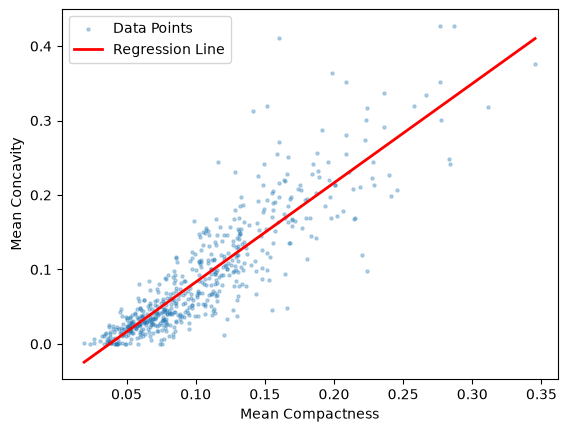

In [38]:
plt.scatter(x_train, y_train, s=5, alpha=0.3, label='Data Points')

x_vals = np.linspace(min(x_train), max(x_train), 100)
y_vals = final_w *x_vals + final_b
plt.plot(x_vals, y_vals, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Mean Compactness")
plt.ylabel("Mean Concavity")
plt.legend()
plt.show()

The red line runs directly through the center of the data cloud, tracking the real upward trend from roughly **(0.02, 0.0)** to **(0.35, 0.44)** — a visually strong fit consistent with the **~0.88** correlation between these two features.


### Sklearn Validation

Fits scikit-learn's **LinearRegression** on the same data, purely as an independent check on correctness

In [42]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(x_train.reshape(-1, 1), y_train)

print(f"From scratch:  w={final_w:.4f}, b={final_b:.4f}")
print(f"sklearn:       w={sk_model.coef_[0]:.4f}, b={sk_model.intercept_:.4f}")

From scratch:  w=1.3331, b=-0.0503
sklearn:       w=1.3331, b=-0.0503


From-scratch and sklearn produce **identical parameters to four decimal places (w=1.3331, b=-0.0503)**, confirming the from-scratch implementation of the cost function, gradients, and gradient descent is mathematically correct.